In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

### **Pydantic schema**

In [3]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    
    topic: str
    insta: str
    twitter: str
    linkedin: str

In [4]:
def create_post_insta(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(f"Write an Instagram post about {topic}. Keep the tone casual and engaging.").content

    # Update the state with the generated post
    state['insta'] = post

    return {'insta' : post}

def create_post_twitter(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a Twitter post
    post = llm.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

    # Update the state with the generated post
    state['twitter'] = post

    return {'twitter' : post}


def create_post_linkedin(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['linkedin'] = post

    return {'linkedin' : post}

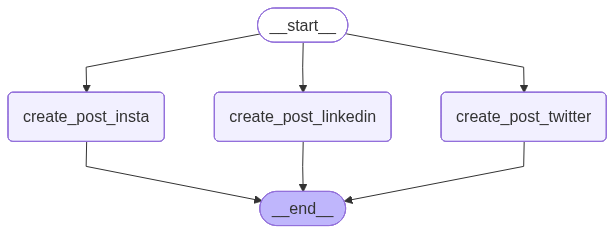

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)


graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_linkedin")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

parallel_graph = graph.compile()



from IPython.display import Image, display

# You could see the errors with the below command
Image(parallel_graph.get_graph().draw_mermaid_png())

In [6]:
parallel_graph.invoke({"topic": "Artificial Intelligence",
                    "insta": "",
                    "twitter": "",
                    "linkedin": ""})

{'topic': 'Artificial Intelligence',
 'insta': 'Here are a few options, pick the one that best fits your vibe!\n\n---\n\n**Option 1 (Focus on everyday magic):**\n\nOkay, let\'s talk about something that\'s *everywhere* but we don\'t always realize it: Artificial Intelligence! 🤖✨\n\nEver scrolled through your feed and wondered how it *just knows* what you want to see? Or asked Siri a random question? Yep, that\'s AI doing its thing! It\'s not just sci-fi movies with robots taking over (phew!). It\'s woven into so much of our daily lives, from recommending your next binge-watch on Netflix to helping doctors diagnose illnesses.\n\nIt\'s constantly evolving, and honestly, it\'s fascinating (and sometimes a little mind-blowing!). What\'s one way you\'ve noticed AI making your life easier (or just more interesting)? Or what\'s your biggest question about it?\n\nDrop your thoughts below! 👇 Let\'s chat about the future (and present!) of AI.\n\n#AI #ArtificialIntelligence #TechTalk #FutureIsNow